# **Intro ML Week 3.3 - Case**
---
**Customer Churn Prediction**

**Task Description:**
- "Churn Rate" is a business term describing the rate at which customers leave or cease paying for a product or service.
- In many businesses, acquiring new customers is a lot more costly than retaining existing ones.
- The goal is to predict whether a customer will churn to competitor.

**Features**
There are 21 variables:
1. State
2. Account Length
3. Area Code
4. Phone
5. Int'l Plan
6. VMail Plan
7. VMail Message
8. Day Mins
9. Day Calls
10. Day Charge
11. Eve Mins
12. Eve Calls
13. Eve Charge
14. Night Mins
15. Night Calls
16. Night Charge
17. Intl Mins
18. Intl Calls
19. Intl Charge
20. CustServ Calls
21. Churn? : Output

# **Workflow**
---

In [1]:
# Import the required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## **Load Data**
---

- Define the function `load_data`.
- It receives one argument `filename`.
- In the function we need to:
    1. Load the data using `pandas` library.
    2. Drop any dupicate data using `pd.drop_duplicates()`


In [2]:
# Function to load csv data.
def load_data(filename):
    """
    Read the csv dataset and return it as pandas dataframe.
    """
    # Load the data in dataframe format.
    df = pd.read_csv(filename)
    print(f"Original data shape      : {df.shape} - (#data, #kolom)")

    # Drop any duplicate data.
    n_duplicates = df.duplicated().sum()
    print(f"The number of duplicates : {n_duplicates}")

    df = df.drop_duplicates()
    print(f"Dropped data shape       : {df.shape} - (#data, #kolom)")

    return df

In [3]:
# Load the data.
FNAME = "3.3-churn.csv"
data = load_data(filename = FNAME)

Original data shape      : (3333, 21) - (#data, #kolom)
The number of duplicates : 0
Dropped data shape       : (3333, 21) - (#data, #kolom)


In [4]:
# Check the top 5 data.
data.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


## **Data Preprocessing**
---
1. Data Split
    - Input-Output (`X`-`y`) Split
    - Train-Test Split
    - Numerical-Categorical Split
2. Imputation
3. Encoding
4. Scaling

### **1 - Data Split**
---

#### **Input-Output (`X`-`y`) Split**

- `y` is the output variable to be predict.
- The rest are input variables.

- Define the function `input_output_split`.
- It receives 2 arguments
    1. `data`
    2. `output_col`
    3. `cols_to_drop`
- In the function we need to:
    1. Drop any unused variables.
    2. Get the input variables by removing the output variable.
    3. Get the output variable using selection.

In [5]:
# Function to split input and output variable.
def input_output_split(data, output_col, cols_to_drop):
    """
    Split the input and output variables.
    """
    data = data.drop(columns = cols_to_drop)

    X = data.drop(output_col,
                  axis = 1)

    y = data[output_col]

    return X, y

In [6]:
# Split the input and output variable.
cols_to_drop = "Phone"
OUTPUT_COL = "Churn?"

X, y = input_output_split(data = data,
                          output_col = OUTPUT_COL,
                          cols_to_drop = cols_to_drop)

In [7]:
# Check the input data.
X.head(2)

,State,Account Length,Area Code,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.7,1
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.7,1


In [8]:
# Check the output data.
y.head(2)

0    False.
1    False.
Name: Churn?, dtype: object

#### **Train-Test Split**

- Train data : to train the model.
- Test data  : simulate the future unseen data.

- We can use `scikit-learn` function [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- It receives several arguments:
    - `X` : the input variables.
    - `y` : the output variable (class).
    - `test_size` : the proportion of test data; e.g. `test_size = 0.2` means 20% of data will be used as the test data.
    - `random_state` : used for reproducibility. We can use any number, but we will use `random_state = 123` for now.

- The `train_test_split` function results 4 outputs:
    1. `X_train` : the train input.
    2. `X_test` : the test input.
    3. `y_train` : the train output.
    4. `y_test` : the test output.
- **Note:** must be in the same order as above.

> Read more: [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [9]:
# Import the train_test_split function.
from sklearn.model_selection import train_test_split

In [10]:
# Split the train and test data.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 123)

# Print the shape of the data.
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

X_train shape : (2666, 19)
X_test shape  : (667, 19)
y_train shape : (2666,)
y_test shape  : (667,)


In [11]:
# Check the data test proportion.
X_test.shape[0] / X.shape[0]

0.2001200120012001

**Important Note:**

- In the preprocessing and modeling phase, we **only** focus to the train data.
- Test data will be used after we get the best model (we will talk more about it in later sessions).

#### **Numerical-Categorical Split**

- Handling numerical data are differs to categorical data; So we need to split them.

In [12]:
# Check the type of each variable.
X_train.dtypes

State              object
Account Length      int64
Area Code           int64
Int'l Plan         object
VMail Plan         object
VMail Message       int64
Day Mins          float64
Day Calls           int64
Day Charge        float64
Eve Mins          float64
Eve Calls           int64
Eve Charge        float64
Night Mins        float64
Night Calls         int64
Night Charge      float64
Intl Mins         float64
Intl Calls          int64
Intl Charge       float64
CustServ Calls      int64
dtype: object

In [13]:
# Get the numerical data.
X_train_num = X_train.select_dtypes(include = ["int64", "float64"])

In [14]:
# Sanity check the numerical data.
X_train_num.head(2)

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
1881,76,415,0,272.7,97,46.36,236.4,95,20.09,235.5,105,10.60,7.7,2,2.08,0
48,119,415,0,159.1,114,27.05,231.3,117,19.66,143.2,91,6.44,8.8,3,2.38,5


- `Area Code` is actually a categorical data.
- So, we need to remove it from `X_train_num`.

In [15]:
# Remove Area Code column from X_train_num.
X_train_num = X_train_num.drop(columns = "Area Code")

X_train_num.head(2)

,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
1881,76,0,272.7,97,46.36,236.4,95,20.09,235.5,105,10.60,7.7,2,2.08,0
48,119,0,159.1,114,27.05,231.3,117,19.66,143.2,91,6.44,8.8,3,2.38,5


In [16]:
num_cols = list(X_train_num.columns)
cat_cols = list(set(X_train.columns).difference(set(num_cols)))

print(f"Numerical Variables:\n{num_cols}\n")
print(f"Categorical Variables:\n{cat_cols}")

Numerical Variables:
['Account Length', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge', 'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls', 'Night Charge', 'Intl Mins', 'Intl Calls', 'Intl Charge', 'CustServ Calls']

Categorical Variables:
["Int'l Plan", 'VMail Plan', 'State', 'Area Code']


In [17]:
# Get the categorical data.
X_train_cat = X_train[cat_cols]

X_train_cat.head(2)

,Int'l Plan,VMail Plan,State,Area Code
1881,no,no,NE,415
48,no,no,ID,415


Nice! Next we move to handling missing values (`NaN`) data.

### **2 - Imputation**
---

#### **Numerical Imputation**

In [18]:
# Check whether exists missing values.
X_train_num.isnull().sum()

Account Length    0
VMail Message     0
Day Mins          0
Day Calls         0
Day Charge        0
Eve Mins          0
Eve Calls         0
Eve Charge        0
Night Mins        0
Night Calls       0
Night Charge      0
Intl Mins         0
Intl Calls        0
Intl Charge       0
CustServ Calls    0
dtype: int64

- No imputation needed.

#### **Categorical Imputation**

In [19]:
# Check whether exists missing values.
X_train_cat.isnull().sum()

Int'l Plan    0
VMail Plan    0
State         0
Area Code     0
dtype: int64

- No imputation needed.

### **3 - Encoding**
---

ML models only receives numerical values; So we need to transform the categorical values we have.

- One of the most common method is using One Hot Encoding (OHE).
- We can utilize the `pd.get_dummies` function.

> Read more: [here](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)

- Define the `ohe_encode` function.
- It receives 2 arguments `data` and `cat_cols`.

In [20]:
# Function to encode categorical values.
def ohe_encode(data, cat_cols):
    """
    Transform the categorical values to numerical values.
    """
    X_train_cat_encoded = pd.get_dummies(data,
                                         dtype = int)

    return X_train_cat_encoded

In [21]:
# Encode the categorical variables.
X_train_cat_encoded = ohe_encode(data = X_train_cat,
                                 cat_cols = cat_cols)

In [22]:
# Check the data before encoding.
X_train_cat.head()

,Int'l Plan,VMail Plan,State,Area Code
1881,no,no,NE,415
48,no,no,ID,415
2886,no,no,PA,408
2294,no,no,WV,510
314,no,no,ID,408


In [23]:
# Check the data after encoding.
X_train_cat_encoded.head()

,Area Code,Int'l Plan_no,Int'l Plan_yes,VMail Plan_no,VMail Plan_yes,State_AK,State_AL,State_AR,State_AZ,State_CA,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
1881,415,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
48,415,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2886,408,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2294,510,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
314,408,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# Store the OHE columns for transforming test data later.
ohe_columns = X_train_cat_encoded.columns
ohe_columns

Index(['Area Code', 'Int'l Plan_no', 'Int'l Plan_yes', 'VMail Plan_no',
       'VMail Plan_yes', 'State_AK', 'State_AL', 'State_AR', 'State_AZ',
       'State_CA', 'State_CO', 'State_CT', 'State_DC', 'State_DE', 'State_FL',
       'State_GA', 'State_HI', 'State_IA', 'State_ID', 'State_IL', 'State_IN',
       'State_KS', 'State_KY', 'State_LA', 'State_MA', 'State_MD', 'State_ME',
       'State_MI', 'State_MN', 'State_MO', 'State_MS', 'State_MT', 'State_NC',
       'State_ND', 'State_NE', 'State_NH', 'State_NJ', 'State_NM', 'State_NV',
       'State_NY', 'State_OH', 'State_OK', 'State_OR', 'State_PA', 'State_RI',
       'State_SC', 'State_SD', 'State_TN', 'State_TX', 'State_UT', 'State_VA',
       'State_VT', 'State_WA', 'State_WI', 'State_WV', 'State_WY'],
      dtype='object')

### **4 - Join the Numerical & Categorical Data**
---

- Let's concat the processed numerical and categorical data into one dataframe.
- We can utilize the `pd.concat` function.

In [25]:
X_train_concat = pd.concat([X_train_num, X_train_cat_encoded],
                           axis = 1)

X_train_concat.head()

,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
1881,76,0,272.7,97,46.36,236.4,95,20.09,235.5,105,...,0,0,0,0,0,0,0,0,0,0
48,119,0,159.1,114,27.05,231.3,117,19.66,143.2,91,...,0,0,0,0,0,0,0,0,0,0
2886,85,0,144.4,88,24.55,264.6,105,22.49,185.4,94,...,0,0,0,0,0,0,0,0,0,0
2294,59,0,189.7,100,32.25,115.9,133,9.85,220.6,115,...,0,0,0,0,0,0,0,0,1,0
314,128,0,125.2,99,21.28,205.4,107,17.46,254.4,111,...,0,0,0,0,0,0,0,0,0,0


In [26]:
# Check the missing values.
X_train_concat.isnull().sum()

Account Length    0
VMail Message     0
Day Mins          0
Day Calls         0
Day Charge        0
                 ..
State_VT          0
State_WA          0
State_WI          0
State_WV          0
State_WY          0
Length: 71, dtype: int64

### **5 - Standardization (Scaling)**
---

- Some variables might have different scale, e.g. `age` and `balance`.
- It might be a problem for some models (we will talk about it later).

We can utilize the `StandardScaler`class from scikit-learn.

> Read more: [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

- Define the `scale_data` function.
- It receives 1 argument `data`.
- In the function we need to:
    1. Create the `StandardScaler` object.
    2. Fit the standardizer on `X_train_concat`.
    3. Transform the data.

In [27]:
# Import the StandardScaler class.
from sklearn.preprocessing import StandardScaler

In [28]:
# Function to scale the data.
def scale_data(data):
    """
    Scale the data using StandardScaler.
    """
    # Create the StandardScaler object.
    scaler = StandardScaler()

    # Fit the standardizer on X_train_concat.
    scaler.fit(data)

    # Transform the data.
    scaled_data = scaler.transform(data)
    X_train_scaled = pd.DataFrame(scaled_data,
                                  columns = data.columns,
                                  index = data.index)

    return scaler, X_train_scaled

In [29]:
# Scale the data.
scaler, X_train_clean = scale_data(data = X_train_concat)

In [30]:
# Check the results.
X_train_clean.head()

,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
1881,-0.607469,-0.58996,1.714374,-0.177334,1.714428,0.704097,-0.248097,0.703106,0.681734,0.250960,...,-0.135405,-0.129542,-0.158083,-0.143784,-0.142419,-0.150437,-0.129542,-0.151736,-0.177016,-0.156833
48,0.476222,-0.58996,-0.380475,0.674057,-0.380209,0.602810,0.856959,0.602636,-1.141555,-0.470287,...,-0.135405,-0.129542,-0.158083,-0.143784,-0.142419,-0.150437,-0.129542,-0.151736,-0.177016,-0.156833
2886,-0.380650,-0.58996,-0.651551,-0.628070,-0.651394,1.264154,0.254201,1.263865,-0.307939,-0.315734,...,-0.135405,-0.129542,-0.158083,-0.143784,-0.142419,-0.150437,-0.129542,-0.151736,-0.177016,-0.156833
2294,-1.035905,-0.58996,0.183807,-0.027089,0.183857,-1.689055,1.660636,-1.689469,0.387401,0.766136,...,-0.135405,-0.129542,-0.158083,-0.143784,-0.142419,-0.150437,-0.129542,-0.151736,5.649211,-0.156833
314,0.703041,-0.58996,-1.005610,-0.077170,-1.006105,0.088431,0.354661,0.088606,1.055084,0.560066,...,-0.135405,-0.129542,-0.158083,-0.143784,-0.142419,-0.150437,-0.129542,-0.151736,-0.177016,-0.156833


Excellent! Now we are ready to modeling phase.

## **Modeling**
---
1. Baseline Model
2. Training Model
3. Testing Model

### **Baseline Model**
---
- The *benchmark* model.
- The trained model performance must exceed the baseline performance.

In [31]:
# Benchmark accuracy.
benchmark = y_train.value_counts(normalize=True).values[0]
print(f"Benchmark Accuracy : {benchmark}")

Benchmark Accuracy : 0.854463615903976


Our model must exceeds $86$% accuracy.

<AxesSubplot:ylabel='Churn?'>

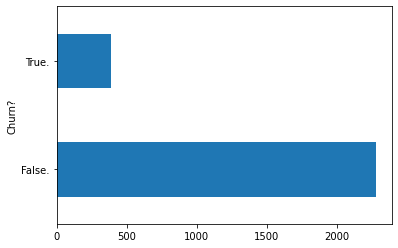

In [32]:
# Plot the class.
y_train.value_counts().plot(kind="barh")

### **Training Model**
---

- We will use `DecisionTreeClassifier` from scikit-learn.

> Read more: [here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

In [33]:
# Import the DecisionTreeClassifier class.
from sklearn.tree import DecisionTreeClassifier

In [34]:
# Create model object.
dt_clf = DecisionTreeClassifier(random_state=123)

# Train the model.
dt_clf.fit(X_train_clean, y_train)

DecisionTreeClassifier(random_state=123)

In [35]:
# Check the accuracy on train data.
acc_train = dt_clf.score(X_train_clean, y_train)
print(f"DT accuracy on train set : {acc_train}")

DT accuracy on train set : 1.0


- Let's tune the `max_depth` hyperparameter using `GridSearchCV` from scikit-learn.

> Read more: [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

In [36]:
# Import the GridSearchCV class.
from sklearn.model_selection import GridSearchCV

In [37]:
# Define the parameter space.
dt_params = {
    "max_depth": list(range(2, 13)),
}

In [38]:
# Do hyperparameter tuning + cross validation.
dt_tuned = GridSearchCV(estimator = dt_clf,
                        param_grid = dt_params,
                        cv = 5,
                        scoring = "accuracy")

dt_tuned.fit(X_train_clean, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=123),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]},
             scoring='accuracy')

In [39]:
# Check the accuracy of tuned DT on train set.
acc_train_tuned = dt_tuned.score(X_train_clean, y_train)
print(f"Tuned DT accuracy on train set : {acc_train_tuned}")

Tuned DT accuracy on train set : 0.9643660915228808


In [40]:
# Check the best hyperparameters.
dt_tuned.best_params_

{'max_depth': 6}

In [41]:
# Get the best model.
dt_best = dt_tuned.best_estimator_
dt_best

DecisionTreeClassifier(max_depth=6, random_state=123)

### **Prepare the Test Prediction**
---

- Define a function called `test_preprocess`.
- It receives several arguments:
    1. `data`
    2. `num_cols`
    3. `cat_cols`    
    4. `scaler`

In [42]:
# Preprocess test data.
def test_preprocess(data, num_cols, cat_cols, scaler):
    """
    Preprocess the test data.
    """
    # Filter the data.
    X_test_num = data[num_cols]
    X_test_cat = data[cat_cols]

    # Categorical encoding.
    cat_encoded = pd.get_dummies(X_test_cat,
                                 dtype = int)
    ohe_cols = cat_encoded.columns
    X_test_cat_encoded = pd.DataFrame(cat_encoded,
                                      columns = ohe_cols,
                                      index = cat_encoded.index)

    # Concat the data.
    concat_data = pd.concat([X_test_num, X_test_cat_encoded],
                             axis = 1)

    # Scale the data.
    scaled_data = scaler.transform(concat_data)
    X_test_clean = pd.DataFrame(scaled_data,
                                columns = concat_data.columns,
                                index = concat_data.index)

    return X_test_clean

In [43]:
# Test the function.
X_test_clean = test_preprocess(data = X_test,
                               num_cols = num_cols,
                               cat_cols = cat_cols,
                               scaler = scaler)

X_test_clean.head()

,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
465,-0.733480,-0.589960,-0.028260,0.623975,-0.028752,-0.658311,-0.298327,-0.659073,-0.373127,0.560066,...,-0.135405,-0.129542,-0.158083,-0.143784,-0.142419,-0.150437,-0.129542,-0.151736,-0.177016,-0.156833
2416,0.325009,-0.589960,-0.437640,2.026266,-0.437700,1.109245,-1.403383,1.109656,-0.507454,1.178277,...,-0.135405,-0.129542,-0.158083,-0.143784,-0.142419,-0.150437,-0.129542,-0.151736,-0.177016,-0.156833
1785,-1.388735,1.530943,-0.810140,0.173239,-0.809766,0.428041,0.053282,0.427399,0.683710,-0.418769,...,-0.135405,-0.129542,-0.158083,-0.143784,-0.142419,-0.150437,-0.129542,-0.151736,-0.177016,-0.156833
1316,-2.270809,-0.589960,0.060255,0.123157,0.060197,0.275117,-1.152234,0.275526,0.106894,-1.397604,...,-0.135405,-0.129542,-0.158083,-0.143784,-0.142419,-0.150437,-0.129542,-0.151736,-0.177016,-0.156833
446,-0.305044,-0.589960,-0.764038,0.774221,-0.764207,0.696153,1.911785,0.696096,-0.432389,0.508548,...,-0.135405,-0.129542,6.325771,-0.143784,-0.142419,-0.150437,-0.129542,-0.151736,-0.177016,-0.156833


In [44]:
# Do prediction on test data.
dt_clf_pred = dt_clf.predict(X_test_clean)
best_pred = dt_best.predict(X_test_clean)

In [45]:
# Performance on test data.
dt_acc_test = dt_clf.score(X_test_clean, y_test)
best_acc_test = dt_best.score(X_test_clean, y_test)

print(f"DT accuracy on test set       : {dt_acc_test}")
print(f"Tuned DT accuracy on test set : {best_acc_test}")

DT accuracy on test set       : 0.9175412293853074
Tuned DT accuracy on test set : 0.9370314842578711


### **Performance Summary**
---

In [46]:
# Create a summary dataframe of train vs test performance.
performance = {
    "Model": ["Baseline", "DT", "Tuned_DT"],
    "Train Accuracy": [benchmark, acc_train, acc_train_tuned],
    "Test Accuracy": [None, dt_acc_test, best_acc_test]
}

summary_df = pd.DataFrame(performance)
summary_df

,Model,Train Accuracy,Test Accuracy
0,Baseline,0.854464,NaN
1,DT,1.000000,0.917541
2,Tuned_DT,0.964366,0.937031


**Summary:**
- All performances exceeds the benchmark.
- Original DT shows a sign of overfit.
- Tuned DT shows a good performance (good fit).